In [1]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv(
    "Ventas_modulo41.csv",
    sep=";",
    encoding="utf-8-sig"
)

Scikit-learn: segmentación de clientes

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

clientes = df.groupby("Cliente").agg(
    Ventas_Totales=("Ventas", "sum"),
    Cantidad_Total=("Cantidad", "sum"),
    Numero_Compras=("Producto", "count"),
    Ticket_Medio=("Ventas", "mean")
).dropna()

X = StandardScaler().fit_transform(clientes)

resultados_k = []

for k in range(2, 7):
    etiquetas = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    ).fit_predict(X)

    resultados_k.append({
        "k": k,
        "silhouette": silhouette_score(X, etiquetas)
    })

print(pd.DataFrame(resultados_k))

   k  silhouette
0  2    0.550939
1  3    0.435594
2  4    0.464133
3  5    0.446491
4  6    0.458520


In [9]:
k_final = 2

clientes["Segmento"] = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
).fit_predict(X)

print(
    clientes.groupby("Segmento")
    .mean(numeric_only=True)
)

          Ventas_Totales  Cantidad_Total  Numero_Compras   Ticket_Medio
Segmento                                                               
0           6.019442e+05      111.270588        3.929412  159151.094412
1           3.533323e+06      668.444444       23.703704  149166.348098


Segmento 0: clientes ocasionales o de menor volumen
Menos compras.
Menor cantidad total.
Ventas totales mucho más bajas.
Ticket medio ligeramente superior.
Este grupo parece estar formado por clientes con poca frecuencia, pero con un valor medio por operación algo mayor.

Segmento 1: clientes frecuentes y de alto volumen
Aproximadamente 24 compras de media frente a 4 del segmento 0.
Mayor cantidad acumulada.
Ventas totales mucho más altas.
Ticket medio ligeramente inferior.
Este es el segmento más importante para la empresa por volumen y recurrencia.

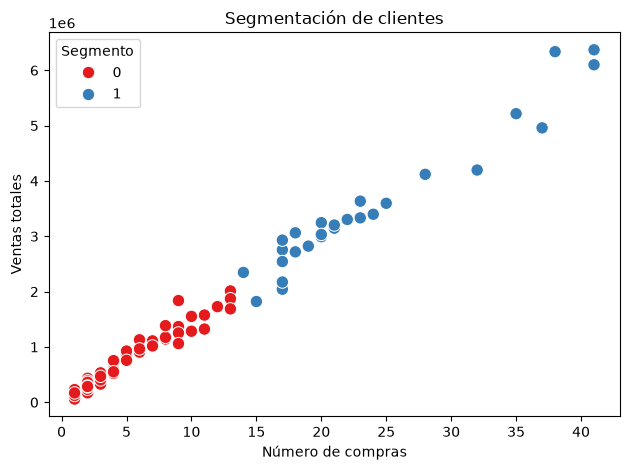

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=clientes,
    x="Numero_Compras",
    y="Ventas_Totales",
    hue="Segmento",
    palette="Set1",
    s=80
)

plt.title("Segmentación de clientes")
plt.xlabel("Número de compras")
plt.ylabel("Ventas totales")
plt.tight_layout()
plt.show()

Segmento 0: aplicar campañas de activación, recomendaciones de productos y promociones para aumentar la frecuencia de compra.

Segmento 1: priorizar fidelización, atención personalizada y ofertas de venta cruzada.

Conviene analizar especialmente los clientes cercanos a la frontera entre ambos grupos, porque podrían pasar al segmento de alto valor mediante acciones comerciales específicas.

NetworkX: red Cliente–Producto

In [12]:
import networkx as nx

relacion = (
    df.groupby(["Cliente", "Producto"], as_index=False)
      .agg(
          Ventas=("Ventas", "sum"),
          Compras=("Producto", "size")
      )
)

red = nx.Graph()

red.add_nodes_from(
    relacion["Cliente"].unique(),
    tipo="Cliente"
)

red.add_nodes_from(
    relacion["Producto"].unique(),
    tipo="Producto"
)

red.add_weighted_edges_from(
    relacion[["Cliente", "Producto", "Ventas"]]
    .itertuples(index=False, name=None)
)

NetworkX:Clientes y productos centrales

In [13]:
clientes_red = [
    n for n, datos in red.nodes(data=True)
    if datos["tipo"] == "Cliente"
]

productos_red = [
    n for n, datos in red.nodes(data=True)
    if datos["tipo"] == "Producto"
]

centralidad_clientes = sorted(
    (
        (n, red.degree(n, weight="weight"))
        for n in clientes_red
    ),
    key=lambda x: x[1],
    reverse=True
)

centralidad_productos = sorted(
    (
        (n, red.degree(n, weight="weight"))
        for n in productos_red
    ),
    key=lambda x: x[1],
    reverse=True
)

print("Clientes centrales:", centralidad_clientes[:10])
print("Productos centrales:", centralidad_productos[:10])

Clientes centrales: [('IFH Peru LTD', 6370002), ('Tiendas Wang', 6336216), ('Banco Egipcio Nacional', 6099551), ('Compañia Minera Poderosa, S.A.', 5215381), ('Minera de Cobre Supremo', 4959063), ('Banco Interno', 4196879), ('Asociacion de Fondos de Pensiones', 4119733), ('Gloria', 3634628), ('CLINICA INTERNACIONAL S.A.', 3595968), ('Minera Hatun Exitokuna', 3398282)]
Productos centrales: [('Accesorios', 55047421), ('Juguetes', 37398809), ('Electrodomesticos', 30126889), ('Viajes', 12129272), ('Calzado', 11862587)]


| Cliente                           | Centralidad ponderada / ventas acumuladas |
| --------------------------------- | ----------------------------------------- |
| IFH Peru LTD                      | 6.370.002                                 |
| Tiendas Wang                      | 6.336.216                                 |
| Banco Egipcio Nacional            | 6.099.551                                 |
| Compañía Minera Poderosa, S.A.    | 5.215.381                                 |
| Minera de Cobre Supremo           | 4.959.063                                 |
| Banco Interno                     | 4.196.879                                 |
| Asociación de Fondos de Pensiones | 4.119.734                                 |
| Gloria                            | 3.634.628                                 |
| CLÍNICA INTERNACIONAL S.A.        | 3.595.968                                 |
| Minera Hatun Exitokuna            | 3.398.282                                 |

Estos son los clientes que concentran mayor valor comercial dentro de la red. Constituyen una base natural para acciones de fidelización, gestión de cuentas clave y ofertas de productos complementarios.

| Producto          | Centralidad ponderada / ventas acumuladas |
| ----------------- | ----------------------------------------- |
| Accesorios        | 55.047.421                                |
| Juguetes          | 37.398.809                                |
| Electrodomésticos | 30.126.889                                |
| Viajes            | 12.129.272                                |
| Calzado           | 11.862.587                                |

Esto indica que Accesorios es el producto con mayor peso económico en las relaciones comerciales de la red, seguido por Juguetes y Electrodomésticos.

qué producto está conectado con más clientes, sin considerar el valor monetario?

In [15]:
productos_por_clientes = sorted(
    (
        (nodo, red.degree(nodo))
        for nodo in productos_red
    ),
    key=lambda x: x[1],
    reverse=True
)

print("Productos por número de clientes:")
print(productos_por_clientes)

Productos por número de clientes:
[('Electrodomesticos', 78), ('Juguetes', 64), ('Accesorios', 64), ('Calzado', 44), ('Viajes', 40)]



Electrodomésticos tiene el mayor alcance comercial: aparece conectado con 78 clientes distintos.

Juguetes y Accesorios tienen 64 clientes cada uno.

Calzado conecta con 44 clientes.

Viajes tiene el menor número de clientes conectados: 40.

Esto es importante porque muestra que el producto con mayor volumen de ventas no tiene por qué ser el que llega a más clientes. Por ejemplo, Accesorios era el producto con mayor centralidad ponderada por ventas, pero Electrodomésticos es el que tiene mayor número de clientes distintos.

Y para saber qué cliente compró más categorías distintas?

In [16]:
clientes_por_productos = sorted(
    (
        (nodo, red.degree(nodo))
        for nodo in clientes_red
    ),
    key=lambda x: x[1],
    reverse=True
)

print("Clientes por número de productos:")
print(clientes_por_productos)

Clientes por número de productos:
[('Banco Egipcio Nacional', 5), ('Banco Interno', 5), ('Compañia Minera Poderosa, S.A.', 5), ('Gloria', 5), ('IFH Peru LTD', 5), ('Maquillajes Unidos', 5), ('Minera Hatun Exitokuna', 5), ('Minera de Cobre Supremo', 5), ('RIMAC Corp', 5), ('SCOTIABANK PERU', 5), ('Seguros Internos SAC', 5), ('Servicios Generales', 5), ('Sociedad de Mineria Nueva', 5), ('Americana de Contactos', 4), ('Asociacion de Fondos de Pensiones', 4), ('Automotores Distribuidos', 4), ('Buenaventura Ingenieros, S.A.', 4), ('CLINICA INTERNACIONAL S.A.', 4), ('Electro Este', 4), ('FORZA S.A.', 4), ('Ferrocarriles Centrales', 4), ('HAUG S.A.', 4), ('Hoteles Corp', 4), ('JJC Contratistas', 4), ('Minera Aventurera', 4), ('NEXTEL PERU S.A.', 4), ('Operadores de Gas', 4), ('Periodicos Nuevos', 4), ('Radios Unidos por el pais', 4), ('SIERRA MACHINES S.A.C.', 4), ('San Martin Inc', 4), ('Seguros Positivos', 4), ('Tiendas Wang', 4), ('Tractores Unidos', 4), ('Transportes CPGQ', 4), ('Banco In

| Número de productos | Interpretación                                                 |
| ------------------- | -------------------------------------------------------------- |
| 5                   | Cliente diversificado: compra todas las categorías disponibles |
| 4                   | Alta diversificación: compra la mayoría de las categorías      |
| 3                   | Diversificación intermedia                                     |
| 2                   | Baja diversificación                                           |
| 1                   | Cliente especializado o con potencial de venta cruzada         |

No significa necesariamente que los clientes con grado 5 gasten más que todos los demás. La métrica solo mide variedad de categorías, no el valor económico de las compras.

Por ejemplo, IFH Peru LTD aparece tanto entre los clientes de mayor centralidad ponderada por ventas como entre los que adquieren los cinco productos. Eso lo convierte en una cuenta especialmente estratégica: combina alto valor comercial con alta diversificación de compra.

Hallazgo de negocio
La red permite separar dos perfiles distintos:

Clientes centrales por valor: concentran las mayores ventas acumuladas.

Clientes diversificados por variedad: compran más categorías distintas.

Es posible que un cliente sea importante en una dimensión y no en la otra. Para una estrategia comercial, los clientes con grado 1 o 2 son los principales candidatos para recomendaciones y campañas de venta cruzada, mientras que los clientes con grado 5 pueden recibir medidas de fidelización y ofertas personalizadas.

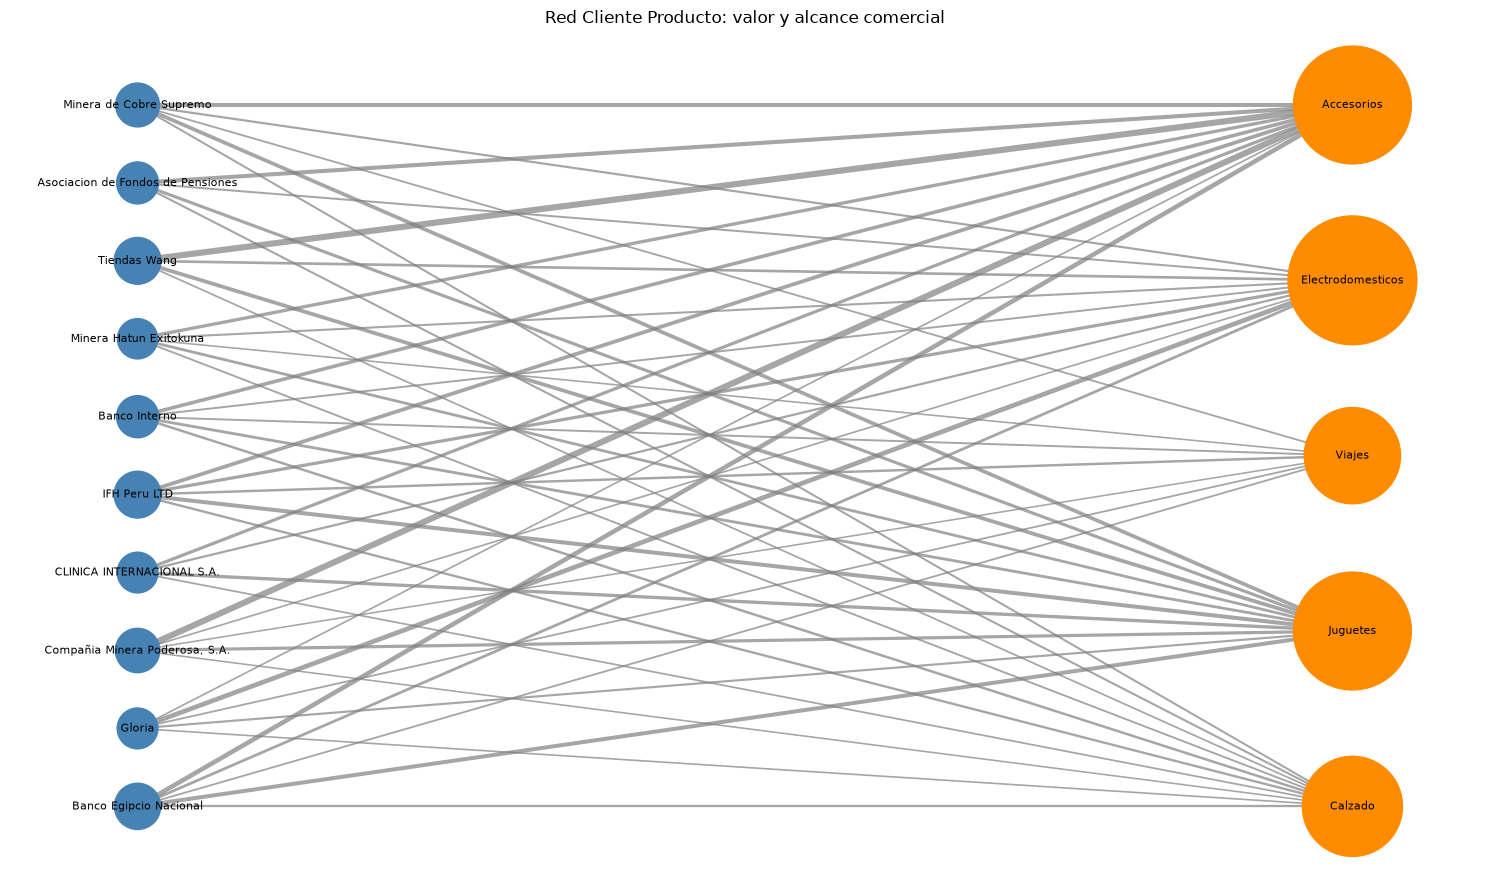

In [26]:
import matplotlib.pyplot as plt
import networkx as nx

top_clientes = [n for n, _ in centralidad_clientes[:10]]
top_productos = [n for n, _ in centralidad_productos[:5]]

nodos = top_clientes + top_productos
subred = red.subgraph(nodos).copy()

pos = nx.bipartite_layout(subred, top_clientes)

clientes_sub = [
    n for n in subred.nodes
    if subred.nodes[n]["tipo"] == "Cliente"
]

productos_sub = [
    n for n in subred.nodes
    if subred.nodes[n]["tipo"] == "Producto"
]

tam_clientes = [
    500 + red.degree(n, weight="weight") / 10000
    for n in clientes_sub
]

tam_productos = [
    800 + red.degree(n) * 100
    for n in productos_sub
]

anchos = [
    1 + subred[u][v]["weight"] / 1_000_000
    for u, v in subred.edges()
]

plt.figure(figsize=(15, 9))

nx.draw_networkx_nodes(
    subred,
    pos,
    nodelist=clientes_sub,
    node_color="steelblue",
    node_size=tam_clientes,
    label="Clientes"
)

nx.draw_networkx_nodes(
    subred,
    pos,
    nodelist=productos_sub,
    node_color="darkorange",
    node_size=tam_productos,
    label="Productos"
)

nx.draw_networkx_edges(
    subred,
    pos,
    width=anchos,
    edge_color="gray",
    alpha=0.7
)

nx.draw_networkx_labels(
    subred,
    pos,
    font_size=8
)

plt.subplots_adjust(right=0.85)
plt.title("Red Cliente Producto: valor y alcance comercial")
plt.axis("off")
plt.tight_layout()
plt.show()

Los clientes aparecen en el lado izquierdo.

Los productos aparecen en el lado derecho.

Cada línea indica que existe una relación comercial Cliente–Producto.

La red se construyó con los clientes y productos principales, por eso no representa todos los registros.

Los clientes que aparecen conectados con las cinco categorías muestran una alta diversificación.

En el lado de los productos:

Accesorios aparece conectado con muchos clientes.

Electrodomésticos también tiene una cobertura amplia.

Juguetes, Viajes y Calzado completan la red con distintos niveles de conexión.

La imagen refuerza el resultado anterior: Accesorios concentra mayor valor económico, mientras que Electrodomésticos conecta con más clientes distintos.